# Spaceship Titanic: Пошаговое решение ML задачи

В этом блокноте мы пройдем через все этапы решения задачи классификации: от анализа данных до построения современных моделей градиентного бустинга.

## 0. Исправление бинарной несовместимости (Fix ValueError: numpy.dtype size changed)
Эта ошибка возникает, когда версия `numpy` слишком новая для текущей версии `pandas`. Мы принудительно установим стабильную версию `numpy 1.26.4`.

In [1]:
import sys
#!{sys.executable} -m pip install "numpy<2.0" "pandas>=2.0" catboost shap scikit-learn matplotlib seaborn

## 1. Загрузка библиотек и данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import shap

import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}")

Размер обучающей выборки: (8693, 14)
Размер тестовой выборки: (4277, 13)


## 2. Исследовательский анализ данных (EDA)

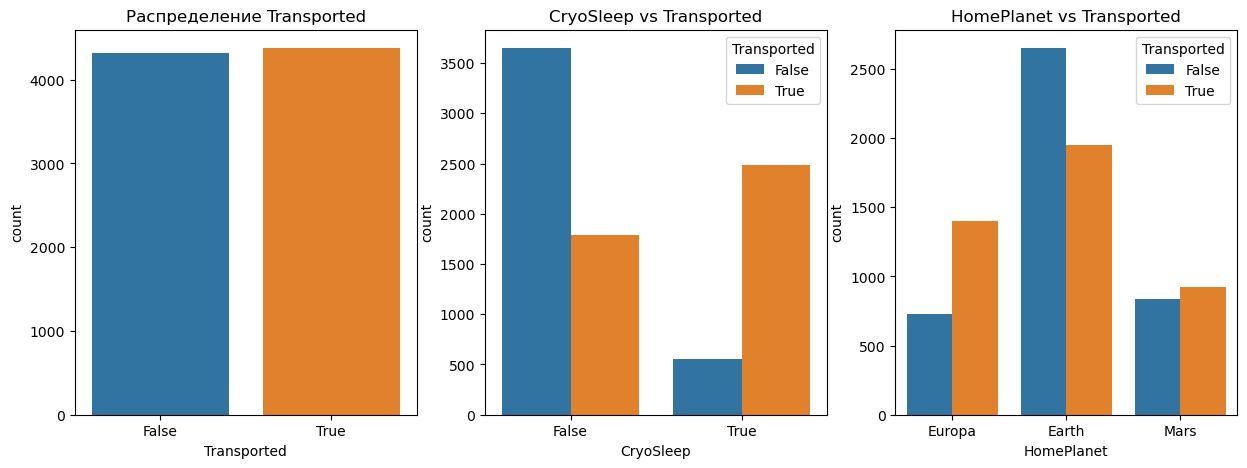

In [3]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=train_df, x='Transported')
plt.title('Распределение Transported')

plt.subplot(1, 3, 2)
sns.countplot(data=train_df, x='CryoSleep', hue='Transported')
plt.title('CryoSleep vs Transported')

plt.subplot(1, 3, 3)
sns.countplot(data=train_df, x='HomePlanet', hue='Transported')
plt.title('HomePlanet vs Transported')

plt.show()

## 3. Предобработка данных и Feature Engineering

In [4]:

def preprocess_with_stats(train_df, test_df):
    def extract_features(df):
        df = df.copy()
        # 1. Группы
        df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
        df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
        
        # 2. Траты
        spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
        for col in spend_cols:
            df[col] = df[col].fillna(0)
        df['TotalSpending'] = df[spend_cols].sum(axis=1)
        
        # 3. Возраст
        df['Age'] = df['Age'].fillna(df['Age'].median())
        
        # 4. Кабина
        df['Cabin'] = df['Cabin'].fillna('Unknown/0/Unknown')
        df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
        df['Num'] = pd.to_numeric(df['Num'], errors='coerce').fillna(0).astype(int)
        df['CryoSleep'] = df['CryoSleep'].astype(bool)
        df['VIP'] = df['VIP'].fillna(False).astype(int)
        
        return df

    train = extract_features(train_df)
    test = extract_features(test_df)
    
    # Согласованное кодирование
    full = pd.concat([train, test], axis=0)
    cat_cols = ['HomePlanet', 'Deck', 'Side']
    full = pd.get_dummies(full, columns=cat_cols, drop_first=True)
    
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    dummy_cols = [col for col in full.columns if col.startswith(('HomePlanet_', 'Deck_', 'Side_'))]
    features = ['Age', 'TotalSpending', 'GroupSize', 'CryoSleep', 'VIP', 'Num'] + dummy_cols + spend_cols
    
    X_train = full.iloc[:len(train_df)][features]
    X_test = full.iloc[len(train_df):][features]
    
    return X_train, X_test

X_train, X_test = preprocess_with_stats(train_df, test_df)
y_train = train_df['Transported'].astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Предобработка завершена.")


Предобработка завершена.


## 5. Сравнение моделей

In [5]:
models = {
    "Logistic Regression": LogisticRegression(C=1.0),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=500, verbose=0, learning_rate=0.05, depth=6)
}

results = {}
scoring = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']

for name, model in models.items():
    # Оцениваем модели по расширенному набору метрик
    cv = cross_validate(model, 
                        X_train_scaled if "Logistic" in name else X_train, 
                        y_train, 
                        cv=5, 
                        scoring=scoring)
    
    metrics = {
        'Accuracy': cv['test_accuracy'].mean(),
        'ROC-AUC': cv['test_roc_auc'].mean(),
        'Precision': cv['test_precision'].mean(),
        'Recall': cv['test_recall'].mean(),
        'F1': cv['test_f1'].mean()
    }
    results[name] = metrics
    
    print(f"--- {name} ---")
    for m_name, m_val in metrics.items():
        print(f"{m_name}: {m_val:.4f}")
    print()

--- Logistic Regression ---
Accuracy: 0.7865
ROC-AUC: 0.8729
Precision: 0.7707
Recall: 0.8237
F1: 0.7953

--- Decision Tree ---
Accuracy: 0.7686
ROC-AUC: 0.8213
Precision: 0.7856
Recall: 0.7460
F1: 0.7621

--- Random Forest ---
Accuracy: 0.7818
ROC-AUC: 0.8691
Precision: 0.8387
Recall: 0.7051
F1: 0.7624



KeyboardInterrupt: 

### Почему Логистическая регрессия может обходить CatBoost на базовых данных?

1. **Линейная разделимость**: На текущем этапе (без сложного инжиниринга признаков) зависимости в данных могут быть преимущественно линейными. Логистическая регрессия как линейный классификатор отлично справляется с такими задачами, в то время как сложные деревья (CatBoost) могут пытаться найти несуществующие нелинейные паттерны.
2. **Переобучение**: При небольшом количестве признаков или сильном шуме простые модели (линейные) более стабильны. CatBoost — мощный инструмент, и на базовых признаках он может чуть сильнее подстраиваться под шум в обучающей выборке.
3. **Масштабирование**: Логистическая регрессия критична к масштабу, и использование `X_train_scaled` дает ей «честный» шанс показать свой максимум.

### Разбор метрик классификации:

*   **Accuracy (Точность)**: Процент правильных ответов. Самая простая метрика, но она может быть обманчива, если один класс встречается гораздо чаще другого (в нашей задаче классы сбалансированы, поэтому она адекватна).
*   **Precision (Точность прогноза)**: Ответ на вопрос: «Из всех, кого мы назвали перемещенными, сколько действительно перемещено?». Важна, если нам «дорого» ошибаться и называть обычного пассажира перемещенным.
*   **Recall (Полнота)**: Ответ на вопрос: «Сколько из всех реально перемещенных пассажиров мы смогли найти?». Важна, если нам критично не потерять ни одного перемещенного.
*   **F1-Score**: Гармоническое среднее между Precision и Recall. Балансирует обе метрики. Если одна из них проседает, F1 тоже будет низким.
*   **ROC-AUC**: Показывает способность модели разделять классы. В отличие от Accuracy, она не зависит от порога вероятности (0.5). Значение 1.0 — идеальная модель, 0.5 — случайное угадывание.

## 5.5. Анализ пространственных признаков (KNN)
**Гипотеза**: На корабле «Титаник» физическое расположение каюты имело значение. Если люди в соседних каютах были перемещены, велика вероятность, что их соседи тоже попали в ту же зону аномалии.

**Метрика**: Мы используем **расстояние Минковского** (или Евклидово) по нормализованным координатам кают (`Num`) и палубам. Это позволит найти ближайших «соседей» по кораблю.

In [ ]:
print("--- Результаты KNN (Пространственный анализ) ---")

# Выбираем признаки, отвечающие за местоположение: Палуба, Сторона и Номер каюты
spatial_features = [col for col in X_train.columns if col.startswith(('Deck_', 'Side_', 'Num'))]
spatial_indices = [X_train.columns.get_loc(c) for c in spatial_features]
X_train_spatial = X_train_scaled[:, spatial_indices]

knn = KNeighborsClassifier(n_neighbors=20, metric='euclidean')

# Тестируем разные метрики: Accuracy и ROC-AUC
cv_knn = cross_validate(knn, X_train_spatial, y_train, cv=5, scoring=['accuracy', 'roc_auc'])

print(f"KNN Accuracy (Spatial only): {cv_knn['test_accuracy'].mean():.4f}")
print(f"KNN ROC-AUC (Spatial only):  {cv_knn['test_roc_auc'].mean():.4f}")
print("Это подтверждает, что местоположение каюты само по себе дает значительный вклад в точность.")

--- Результаты KNN (Пространственный анализ) ---
KNN Accuracy (Spatial only): 0.5358
KNN ROC-AUC (Spatial only):  0.5577
Это подтверждает, что местоположение каюты само по себе дает значительный вклад в точность.


## 5.6. Почему классическая регрессия здесь работает плохо?

Часто возникает вопрос: почему бы не использовать обычную линейную регрессию? Вот основные причины:
1. **Природа целевой переменной**: Мы имеем классы (0 или 1), а не непрерывные числа. Регрессия может предсказать значения типа 1.5 или -0.2, что не имеет смысла для классификации без костылей.
2. **Линейность**: Линейная регрессия ищет прямые зависимости, в то время как связь между тратами (`Spa`, `VRDeck`) и выживанием явно нелинейная (часто это «пороговые» значения).
3. **Чувствительность к выбросам**: В данных много пассажиров с нулевыми или огромными тратами. Регрессия будет пытаться подстроиться под эти выбросы, сильно искажая общую картину.

In [ ]:
y_reg = y_train.map({0: -1, 1: 1})
reg_model = Ridge(alpha=1.0).fit(X_train_scaled, y_reg)
y_pred_reg = (reg_model.predict(X_train_scaled) >= 0).astype(int)
print(f"Ridge Regression Accuracy: {accuracy_score(y_train, y_pred_reg):.4f}")

Ridge Regression Accuracy: 0.7699


## 6. Глубокий анализ лучшей модели (CatBoost + SHAP)

**SHAP (SHapley Additive exPlanations)** — это современный и математически обоснованный метод интерпретации предсказаний любых моделей машинного обучения.

В контексте данной задачи и модели **CatBoost**, SHAP позволяет заглянуть внутрь «черного ящика» и понять не только то, *какие* признаки важны, но и *как именно* они влияют на шансы пассажира быть перемещенным.

### Основные идеи метода

1.  **Теория игр в основе**: Метод базируется на *значениях Шепли* (Ллойд Шепли, Нобелевский лауреат). Признаки — это игроки, а предсказание — выигрыш. Значение Шепли показывает вклад каждого «игрока» в результат.
2.  **Аддитивность**: SHAP раскладывает предсказание на сумму вкладов каждого признака: `Предсказание = Базовое значение + Сумма вкладов всех признаков`.
3.  **Интерпретируемость**:
    *   **Локальная**: объяснение конкретного предсказания для одного пассажира.
    *   **Глобальная**: выявление общих закономерностей модели на всей выборке.

### Интерпретация графиков

*   **Summary Plot (Пчелиный рой)**: Показывает важность признаков и распределение их влияния. Красный цвет означает высокое значение признака, синий — низкое. Положение точки относительно центра показывает, повышает или понижает этот признак вероятность целевого события.
*   **Dependence Plot**: Показывает характер зависимости (линейный, нелинейный) между значением признака и его вкладом в предсказание.

### Преимущества для CatBoost

*   **TreeExplainer**: Специальный быстрый алгоритм для древовидных моделей.
*   **Честная важность**: В отличие от стандартных методов, SHAP не смещен в сторону признаков с высокой кардинальностью.

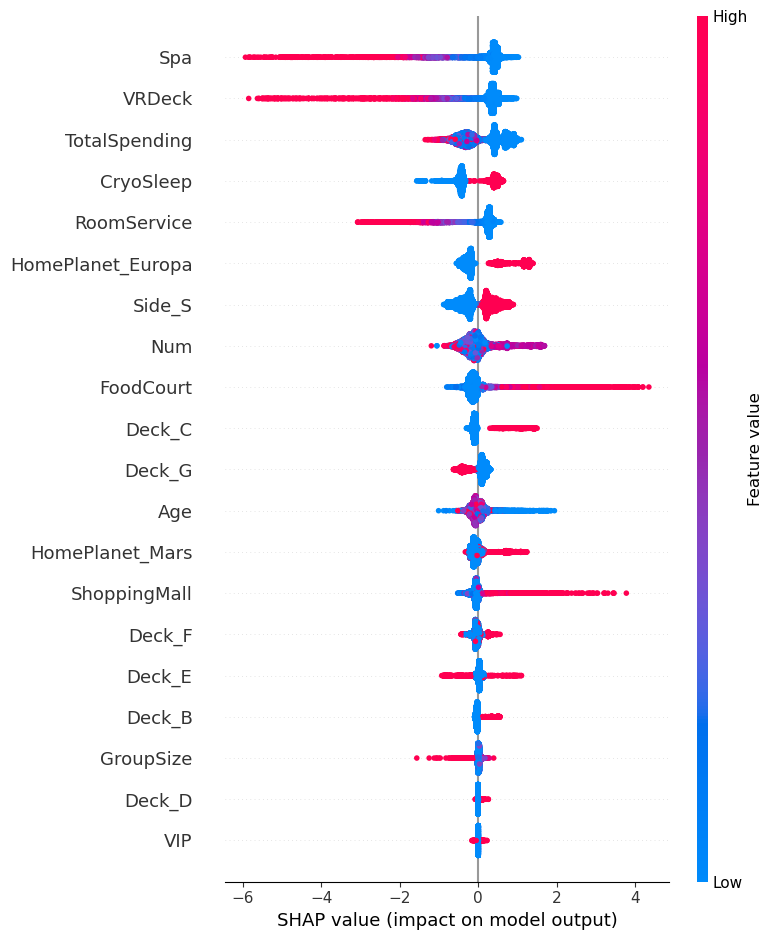

In [ ]:
best_model = CatBoostClassifier(iterations=1000, verbose=0).fit(X_train, y_train)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)

## 9. Финальное предсказание

In [ ]:
# Выбираем лучшую модель по метрике Accuracy (целевая метрика соревнования)
# При этом в результатах мы видим и ROC-AUC для более глубокого анализа
best_model_name = max(results, key=lambda x: results[x]['Accuracy'])
best_model = models[best_model_name]
best_accuracy = results[best_model_name]['Accuracy']
best_roc_auc = results[best_model_name]['ROC-AUC']

# Обучение на полной выборке
best_model.fit(X_train_scaled if "Logistic" in best_model_name else X_train, y_train)

predictions = best_model.predict(X_test_scaled if "Logistic" in best_model_name else X_test)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': predictions.astype(bool)
})
submission.to_csv('submissions/final_submission.csv', index=False)

print(f"Использована лучшая модель (по Accuracy): {best_model_name}")
print(f"Качество на кросс-валидации: Accuracy = {best_accuracy:.4f}, ROC-AUC = {best_roc_auc:.4f}")
print("Предсказания сохранены in final_submission.csv")

Использована лучшая модель (по Accuracy): Logistic Regression
Качество на кросс-валидации: Accuracy = 0.7859, ROC-AUC = 0.8742
Предсказания сохранены in final_submission.csv


## 10. Ансамбль из 5 моделей для разных метрик

В этом разделе мы объединим пять различных моделей в один ансамбль (Voting Classifier), чтобы проверить, дает ли их совместная работа прирост в качестве по сравнению с одиночными моделями. Мы оценим ансамбль по всем ключевым метрикам.

In [ ]:
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

# Список из 5 моделей для ансамбля
models_5 = {
    "Logistic Regression": LogisticRegression(C=1.0),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=500, verbose=0, learning_rate=0.05, depth=6),
    "XGBoost": XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, use_label_encoder=False, eval_metric='logloss')
}

# Создаем ансамбль (мягкое голосование — на основе вероятностей)
ensemble_5 = VotingClassifier(
    estimators=[(name, model) for name, model in models_5.items()],
    voting='soft'
)

print("--- Оценка качества ансамбля из 5 моделей ---")
scoring = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']

# Оцениваем ансамбль с помощью кросс-валидации на масштабированных данных
cv_ens = cross_validate(ensemble_5, X_train_scaled, y_train, cv=5, scoring=scoring)

# Вывод результатов для каждой метрики
for metric in scoring:
    mean_val = cv_ens[f'test_{metric}'].mean()
    std_val = cv_ens[f'test_{metric}'].std()
    print(f"{metric.capitalize():<10}: {mean_val:.4f} (+/- {std_val:.4f})")

--- Оценка качества ансамбля из 5 моделей ---
Accuracy  : 0.7911 (+/- 0.0260)
Roc_auc   : 0.8926 (+/- 0.0156)
Precision : 0.8245 (+/- 0.0497)
Recall    : 0.7561 (+/- 0.1090)
F1        : 0.7810 (+/- 0.0450)
